In [1]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import torch
print(torch.cuda.is_available())
print(torch.version.cuda)

True
12.1


In [2]:
# load files
pred = pd.read_csv('datasets/whole_dataset.csv')
true = pd.read_csv('datasets/sift-data.csv')

In [3]:
pred['variant_id'] = pred['RefSeq'] + ':' + pred['c. Change']

extracted = true['Name'].str.extract(r'^([A-Z0-9_\.]+)\([^)]+\):(\S+)')
true['variant_id'] = extracted[0] + ':' + extracted[1]


In [4]:
# merge on that key
merged = pd.merge(pred, true, on='variant_id', how='inner')
print("Merged shape:", merged.shape)
merged.head()

Merged shape: (4308, 25)


,Gene,RefSeq,Transcript,c. Change,SIFT Prediction,SIFT Score,variant_id,Name,Gene(s),Protein change,...,GRCh38Location,VariationID,AlleleID(s),dbSNP ID,Canonical SPDI,Variant type,Molecular consequence,Germline classification,Germline date last evaluated,Germline review status
0,KRAS,NM_033360.4,ENST00000256078,c.194G>T,deleterious_low_confidence,0.00,NM_033360.4:c.194G>T,NM_033360.4(KRAS):c.194G>T (p.Ser65Ile),KRAS,S65I,...,25227330.0,438796,432423.0,rs1555194026,NC_000012.12:25227329:C:A,single nucleotide variant,missense variant,Likely pathogenic,5/18/2020,reviewed by expert panel
1,NTRK3,NM_001012338.3,ENST00000629765,c.61G>T,deleterious_low_confidence,0.01,NM_001012338.3:c.61G>T,NM_001012338.3(NTRK3):c.61G>T (p.Val21Phe),NTRK3|NTRK3-AS1,V21F,...,88256093.0,719029,726314.0,rs200822610,NC_000015.10:88256092:C:A,single nucleotide variant,missense variant,Likely benign,12/31/2019,"criteria provided, single submitter"
2,IDH2,NM_002168.4,ENST00000330062,c.890T>C,tolerated_low_confidence,0.66,NM_002168.4:c.890T>C,NM_002168.4(IDH2):c.890T>C (p.Val297Ala),IDH2,"V245A, V297A, V167A",...,90087189.0,435488,429745.0,rs538460237,NC_000015.10:90087188:A:G,single nucleotide variant,missense variant,Likely benign,8/22/2022,"criteria provided, multiple submitters, no con..."
3,IDH2,NM_002168.4,ENST00000330062,c.782G>A,deleterious_low_confidence,0.01,NM_002168.4:c.782G>A,NM_002168.4(IDH2):c.782G>A (p.Arg261His),IDH2,"R209H, R261H, R131H",...,90087472.0,211177,208231.0,rs118101777,NC_000015.10:90087471:C:T,single nucleotide variant,missense variant,Benign/Likely benign,1/19/2025,"criteria provided, multiple submitters, no con..."
4,APOE,NM_000041.4,ENST00000446996,c.461G>T,deleterious,0.00,NM_000041.4:c.461G>T,NM_000041.4(APOE):c.461G>T (p.Arg154Leu),APOE,"R154L, R180L",...,44908757.0,375636,362450.0,rs200703101,NC_000019.10:44908756:G:T,single nucleotide variant,missense variant,Likely pathogenic,12/21/2015,"criteria provided, single submitter"


In [5]:
merged.columns

Index(['Gene', 'RefSeq', 'Transcript', 'c. Change', 'SIFT Prediction',
       'SIFT Score', 'variant_id', 'Name', 'Gene(s)', 'Protein change',
       'Condition(s)', 'Accession', 'GRCh37Chromosome', 'GRCh37Location',
       'GRCh38Chromosome', 'GRCh38Location', 'VariationID', 'AlleleID(s)',
       'dbSNP ID', 'Canonical SPDI', 'Variant type', 'Molecular consequence',
       'Germline classification', 'Germline date last evaluated',
       'Germline review status'],
      dtype='object')

In [6]:
# columns useful for classification
columns_to_keep = [
    'variant_id', 'SIFT Prediction', 'SIFT Score', 'Germline classification'
]
filtered_df = merged[columns_to_keep]
filtered_df



,variant_id,SIFT Prediction,SIFT Score,Germline classification
0,NM_033360.4:c.194G>T,deleterious_low_confidence,0.00,Likely pathogenic
1,NM_001012338.3:c.61G>T,deleterious_low_confidence,0.01,Likely benign
2,NM_002168.4:c.890T>C,tolerated_low_confidence,0.66,Likely benign
3,NM_002168.4:c.782G>A,deleterious_low_confidence,0.01,Benign/Likely benign
4,NM_000041.4:c.461G>T,deleterious,0.00,Likely pathogenic
...,...,...,...,...
4303,NM_000059.4:c.7976G>A,deleterious,0.00,Pathogenic/Likely pathogenic
4304,NM_000059.4:c.9004G>A,deleterious,0.00,Pathogenic/Likely pathogenic
4305,NM_007294.4:c.181T>G,deleterious,0.00,Pathogenic
4306,NM_000059.4:c.8350C>T,deleterious,0.00,Pathogenic/Likely pathogenic


In [7]:
normalized_df = filtered_df
# SIFT pred into binary: deleterious vs tolerated
normalized_df['SIFT_bin'] = normalized_df['SIFT Prediction'].str.contains('deleterious', case=False).map({True: 'pathogenic', False: 'benign'})

# map germline classification into binary labels
normalized_df['true_label'] = normalized_df['Germline classification'].str.lower().map(lambda x: 'pathogenic' if 'pathogenic' in x else 'benign')

# compute classification metrics
y_pred = normalized_df['SIFT_bin']
y_true = normalized_df['true_label']

# y_pred

C:\Users\brian\AppData\Local\Temp\ipykernel_6436\3196204544.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  normalized_df['SIFT_bin'] = normalized_df['SIFT Prediction'].str.contains('deleterious', case=False).map({True: 'pathogenic', False: 'benign'})
C:\Users\brian\AppData\Local\Temp\ipykernel_6436\3196204544.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  normalized_df['true_label'] = normalized_df['Germline classification'].str.lower().map(lambda x: 'pathogenic' if 'pathogenic' in x else 'benign'

In [8]:
# balance the dataset by undersampling the majority class
benign_df = normalized_df[normalized_df["true_label"] == "benign"]
patho_df = normalized_df[normalized_df["true_label"] == "pathogenic"]
patho_sampled = patho_df.sample(n=len(benign_df), random_state=42)

balanced_df = pd.concat([benign_df, patho_sampled]).sample(frac=1, random_state=42)


y_true = balanced_df["true_label"]
y_pred = balanced_df["SIFT_bin"]

In [9]:
metrics = {
    'Accuracy': accuracy_score(y_true, y_pred),
    'Precision': precision_score(y_true, y_pred, pos_label='pathogenic'),
    'Recall': recall_score(y_true, y_pred, pos_label='pathogenic'),
    'F1 Score': f1_score(y_true, y_pred, pos_label='pathogenic'),
}
metrics

{'Accuracy': 0.7115107913669064,
 'Precision': 0.6446850393700787,
 'Recall': 0.9424460431654677,
 'F1 Score': 0.7656341320864991}

In [10]:
conf_matrix = confusion_matrix(y_true, y_pred, labels=['pathogenic', 'benign'])
class_report = classification_report(y_true, y_pred, labels=['pathogenic', 'benign'], output_dict=True)

metrics_df = pd.DataFrame.from_dict(metrics, orient='index', columns=['Value'])
conf_df = pd.DataFrame(conf_matrix, index=['True Pathogenic', 'True Benign'], columns=['Pred Pathogenic', 'Pred Benign'])


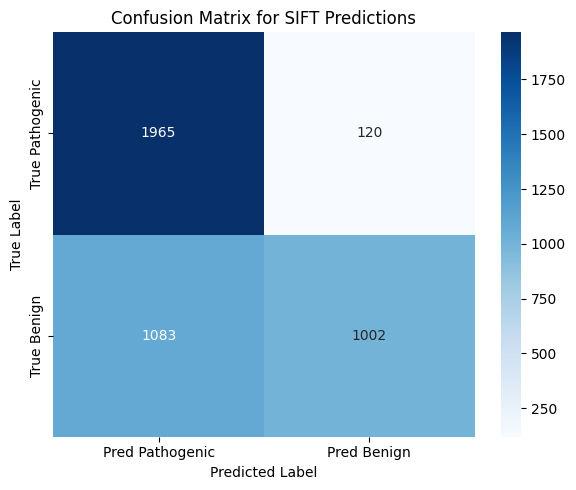

In [11]:
plt.figure(figsize=(6, 5))
sns.heatmap(conf_df, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix for SIFT Predictions")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

C:\Users\brian\AppData\Local\Temp\ipykernel_6436\2969159430.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=metrics_df.index, x=metrics_df['Value'], palette='coolwarm')


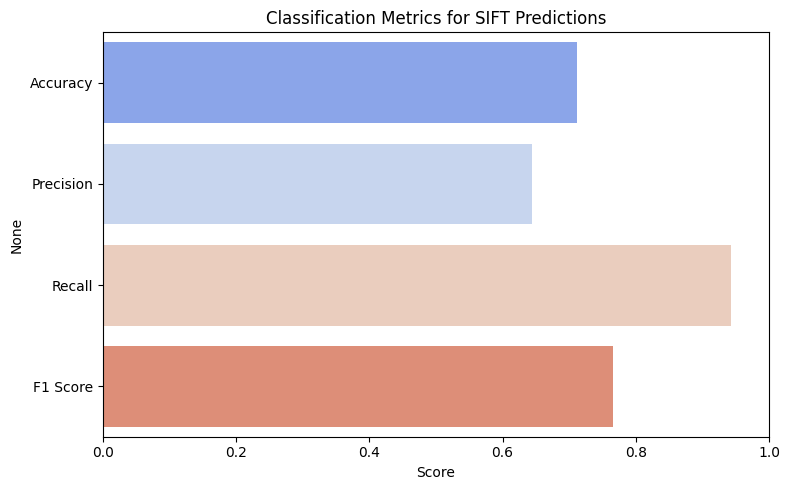

In [12]:
# Bar plot of the metrics from metrics_df
plt.figure(figsize=(8, 5))
sns.barplot(y=metrics_df.index, x=metrics_df['Value'], palette='coolwarm')
plt.title("Classification Metrics for SIFT Predictions")
plt.xlabel("Score")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

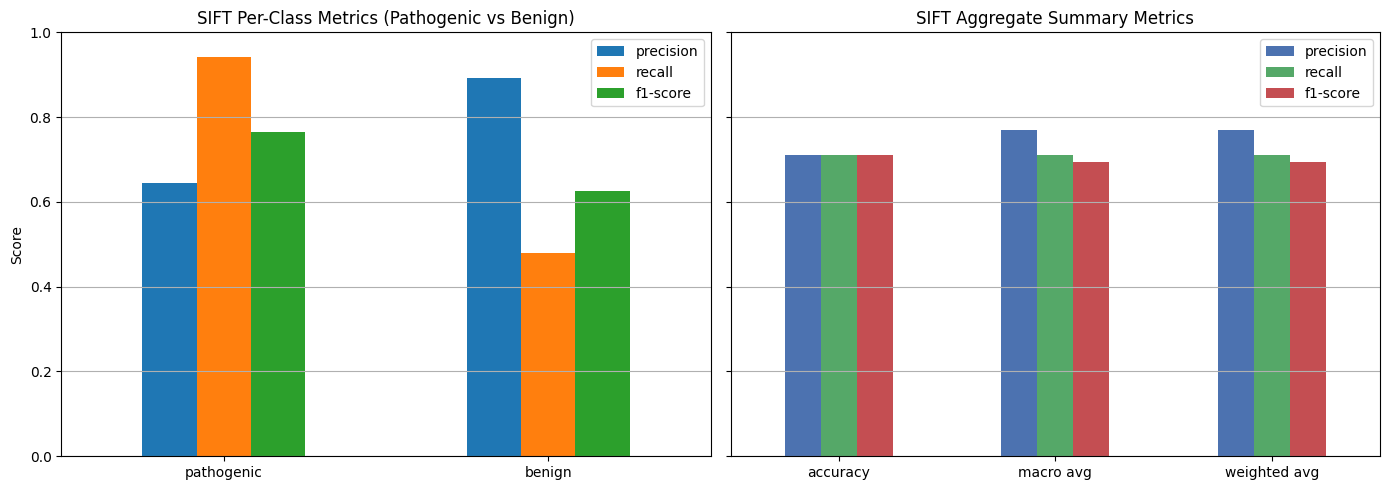

In [13]:
report_df = pd.DataFrame(class_report).transpose()

# Separate the report into class-specific and summary (aggregate) rows
class_metrics = report_df.loc[['pathogenic', 'benign']]
summary_metrics = report_df.loc[['accuracy', 'macro avg', 'weighted avg']]

# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Plot per-class metrics
class_metrics[['precision', 'recall', 'f1-score']].plot(kind='bar', ax=axes[0])
axes[0].set_title("SIFT Per-Class Metrics (Pathogenic vs Benign)")
axes[0].set_ylabel("Score")
axes[0].set_ylim(0, 1)
axes[0].grid(True, axis='y')
axes[0].set_xticklabels(class_metrics.index, rotation=0)

# Plot aggregate summary metrics
summary_metrics[['precision', 'recall', 'f1-score']].plot(kind='bar', ax=axes[1], color=['#4c72b0', '#55a868', '#c44e52'])
axes[1].set_title("SIFT Aggregate Summary Metrics")
axes[1].set_ylim(0, 1)
axes[1].grid(True, axis='y')
axes[1].set_xticklabels(summary_metrics.index, rotation=0)

plt.tight_layout()
plt.show()

In [14]:
print(pd.DataFrame(class_report).transpose())

              precision    recall  f1-score      support
pathogenic     0.644685  0.942446  0.765634  2085.000000
benign         0.893048  0.480576  0.624883  2085.000000
accuracy       0.711511  0.711511  0.711511     0.711511
macro avg      0.768867  0.711511  0.695259  4170.000000
weighted avg   0.768867  0.711511  0.695259  4170.000000
